# Нейронная сеть прямого распространения (классификатор)


**Нейронная сеть прямого распространения** — это один из базовых типов искусственных нейронных сетей, в котором сигнал движется строго от входного слоя к выходному без циклов и обратных связей (в отличие от рекуррентных сетей). В режиме классификатора такая сеть предсказывает вероятность принадлежности объекта к одному из нескольких дискретных классов на основе входных признаков.

**Архитектура**

* Входной слой (число нейронов = числу признаков)
* 1+ скрытых слоёв (обычно с ReLU-активацией)
* Выходной слой:
1. для бинарной классификации: 1 нейрон с сигмоидной активацией (выход — вероятность класса 1)
2. для многоклассовой классификации: K нейронов (K — число классов) с активацией softmax (выход — распределение вероятностей по классам)

**Принцип**

Сигнал идёт строго слева направо (прямое распространение) без циклов. На выходе получаем вектор вероятностей классов. Решение принимается в пользу класса с максимальной вероятностью.

**Обучение**

Минимизация категориальной кросс-энтропии (Categorical Cross‑Entropy) для многоклассовой задачи или бинарной кросс-энтропии (Binary Cross‑Entropy) для двух классов. Используется обратное распространение ошибки (градиентный спуск, Adam и др.). Веса инициализируются случайно, затем корректируются. Для оценки качества применяют точность (accuracy), F1‑меру, матрицу ошибок.

# Используемые библиотеки

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
import re
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Описание и демонстрация датасета

Датасет **Drug Classification** — это небольшой набор данных (200 строк, 6 столбцов), идеально подходящий для решения задачи многоклассовой классификации. Он включает пять признаков пациентов: Age (возраст), Sex (пол), BP (уровень артериального давления), Cholesterol (уровень холестерина), Na_to_K (соотношение натрия и калия в крови), и целевую переменную — тип лекарства Drug.



In [ ]:
path = kagglehub.dataset_download("prathamtripathi/drug-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'drug-classification' dataset.
Path to dataset files: /kaggle/input/drug-classification


In [ ]:
df = pd.read_csv(path + '/drug200.csv')

TARGET = 'Drug'

# таргет
y = df[TARGET]

# признаки
X = df.drop(columns=[TARGET])

In [ ]:
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043


Разобьем выборку на обучение и тест с помощью `train_test_split`

# Препроцессинг датасета

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 7.9+ KB


In [ ]:
numerical_cols = ['Age', 'Na_to_K']
categorical_cols = ['Sex', 'BP', 'Cholesterol']

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols) # drop='first' для избежания мультиколлинеарности
    ])

X_processed = preprocessor.fit_transform(X)

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Тепловая карта

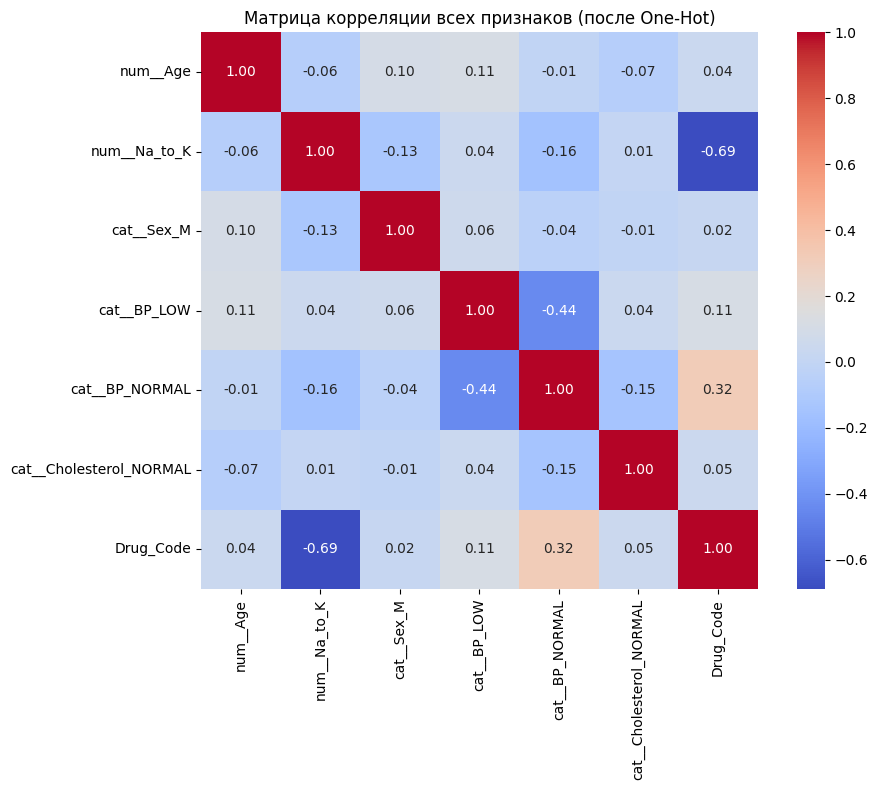

In [ ]:
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_processed, 'toarray'):
    X_processed_dense = X_processed.toarray()
else:
    X_processed_dense = X_processed

df_processed = pd.DataFrame(X_processed_dense, columns=feature_names)

df_processed['Drug_Code'] = y_encoded

corr_full = df_processed.corr()

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Матрица корреляции всех признаков (после One‑Hot)')
plt.tight_layout()
plt.show()

# Обучение модели

Обучаем модель

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(20,10),
    activation='relu',
    max_iter=500,
    random_state=42,
    verbose=True
)

print("\nНачало обучения MLP...")
mlp.fit(X_train, y_train)

# --- Предсказание на тестовой выборке ---
y_pred = mlp.predict(X_test)


Начало обучения MLP...
Iteration 1, loss = 2.13192886
Iteration 2, loss = 2.12029009
Iteration 3, loss = 2.10869769
Iteration 4, loss = 2.09712083
Iteration 5, loss = 2.08554343
Iteration 6, loss = 2.07398534
Iteration 7, loss = 2.06247093
Iteration 8, loss = 2.05089311
Iteration 9, loss = 2.03937670
Iteration 10, loss = 2.02791151
Iteration 11, loss = 2.01654848
Iteration 12, loss = 2.00519286
Iteration 13, loss = 1.99380087
Iteration 14, loss = 1.98248931
Iteration 15, loss = 1.97117487
Iteration 16, loss = 1.95993692
Iteration 17, loss = 1.94870273
Iteration 18, loss = 1.93750083
Iteration 19, loss = 1.92631440
Iteration 20, loss = 1.91522622
Iteration 21, loss = 1.90420051
Iteration 22, loss = 1.89320761
Iteration 23, loss = 1.88219183
Iteration 24, loss = 1.87112841
Iteration 25, loss = 1.86006299
Iteration 26, loss = 1.84900973
Iteration 27, loss = 1.83796144
Iteration 28, loss = 1.82692606
Iteration 29, loss = 1.81587315
Iteration 30, loss = 1.80479612
Iteration 31, loss = 1.79

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Тестирование модели

Делаем предсказание

## Обзор метрик

Получаем метрики


Точность модели на тестовых данных: 1.0000 (100.00%)

Детальный отчёт по классификации:
              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        27
       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



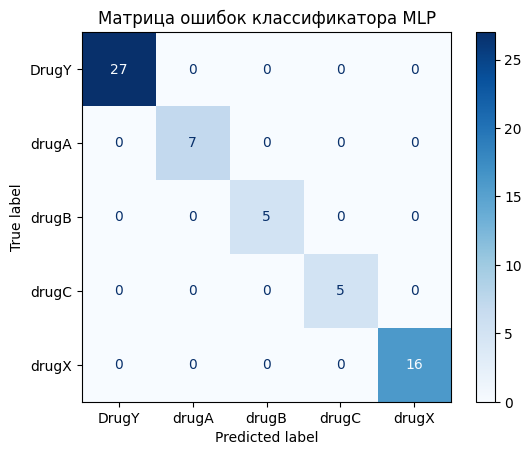

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность модели на тестовых данных: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nДетальный отчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# --- Матрица ошибок (Confusion Matrix) ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок классификатора MLP')
plt.show()